In [1]:
# employee data analysis & insights 

In [2]:
import pandas as pd 

In [3]:
# load the employee datase

emp= pd.read_csv("Downloads/employee_raw_dirty_pandas.csv")
emp

empaln=emp.style.set_properties(**{'text_align' : 'center'})


In [4]:
# understanding of dataset

emp.info()
emp.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         170 non-null    object 
 1   Name                170 non-null    object 
 2   Age                 161 non-null    float64
 3   Gender              157 non-null    object 
 4   Department          170 non-null    object 
 5   Job_Title           170 non-null    object 
 6   Salary              163 non-null    float64
 7   Joining_Date        170 non-null    object 
 8   Experience_Years    160 non-null    float64
 9   Performance_Rating  157 non-null    float64
 10  City                163 non-null    object 
 11  Education_Level     159 non-null    object 
dtypes: float64(4), object(8)
memory usage: 16.1+ KB


,Age,Salary,Experience_Years,Performance_Rating
count,161.000000,1.630000e+02,160.000000,157.000000
mean,41.024845,8.764877e+04,8.537500,3.560510
std,15.915775,1.454847e+05,5.882377,1.178534
min,0.000000,1.000000e+02,-3.000000,1.000000
25%,30.000000,4.815000e+04,4.000000,3.000000
50%,41.000000,6.400000e+04,8.000000,4.000000
75%,51.000000,8.060000e+04,13.000000,4.000000
max,150.000000,1.200000e+06,20.000000,5.000000


In [5]:
# cleaning the dataset

emp.columns = emp.columns.str.lower()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format


# fill the salary 
emp['salary']= emp['salary'].fillna(emp['salary'].mean())

# fill the age 
emp['age'] = emp['age'].fillna(emp['age'].median())

# fill the city
emp['city']= emp['city'].fillna('unknown')

# make joining_date --> datetime
emp['joining_date'] = pd.to_datetime(emp['joining_date'], format='mixed', dayfirst=True)

# handle the gender
emp['gender']= emp['gender'].fillna('unknown')



# Convert every string in the entire table to lowercase
emp = emp.map(lambda x: x.lower() if isinstance(x, str) else x)



# handle the experience_years
emp['experience_years'] = emp['experience_years'].fillna(emp['experience_years'].median())

#handle the performance_rating 
emp['performance_rating'] = emp['performance_rating'].fillna(emp['performance_rating'].median())

# handle the education_level
emp['education_level'] = emp['education_level'].fillna("unknown")




# replacing the wording in columns : 

emp['gender'] = emp['gender'].replace({
    "M" : "male",
    "Male" : "male",
    "MALE" : "male",
    "m": "male",
    "F": "female",
    "f": "female",
    "Female" : "female",
    "FEMALE" : "female"
})

emp['gender'] = emp['gender'].str.strip()



emp['job_title'] = emp['job_title'].str.replace('finacial', 'financial', regex=False)
emp['job_title'] = emp['job_title'].str.replace('oprations', 'operations', regex=False)



emp['department'] = emp['department'].replace({
    "finanace" : "finance",
    "financee" : "finance",
    "finanace" : "finance",
    "h.r" : "hr",
    "i.t": "it",
    "marketting": "marketing",
    "mktg": "marketing",
    "oprations" : "operations",
    "ops": "operations",
    "saless" : "sales"
})
emp['department'] = emp['department'].str.strip()



emp['city'] = emp['city'].replace({
    "ahemdabad" : "ahmedabad",
    "ahmadabad" : "ahmedabad",
    "bangaluru" : "bangalore",
    "bengaluru" : "bangalore",
    "chenai": "chennai",
    "madras" : "chennai",
    "dellhi": "delhi",
    "hyd": "Hyderabad",
    "hydrabad" : "Hyderabad",
    "Hyderabad" : "Hyderabad",
    "calcutta": "kolkata",
    "kolkatta" : "kolkata",
    "Kolkata" : "kolkata",
    "saless" : "sales",
    "mumbai" : "mumbai",
    "puna" : "pune"
    
})

emp['city'] = emp['city'].str.strip()



In [6]:
# Data Transformation

# add bonus column
emp['bonus'] = emp['salary'] * 0.1

ma = emp['salary'].max()
mi = m = emp['salary'].min()


# add category of salary segmentation 
emp['salary_seg'] = emp['salary'].apply(
    lambda x: 'low' if x <= 30000 else "moderate" if x <= 70000 else "high"
)


# add the age group 
emp['age_group'] = emp['age'].apply(
    lambda x: 'young' if x <= 25 else "adult" if x <= 40 else "senior"
)

#  add the experience segment 
emp['exp_level_seg'] = emp['experience_years'].apply(
    lambda x: 'moderate' if x <= 5 else 'higher' if x <= 10 else 'great' if x <= 15
    else 'great_senior' 
)

#  add performance segment 
emp['perform_seg'] = emp['performance_rating'].apply(
    lambda x: 'low' if x <= 2 else 'good' if x <= 4 else 'best' 
)

emp

,employee_id,name,age,gender,department,job_title,salary,joining_date,experience_years,performance_rating,city,education_level,bonus,salary_seg,age_group,exp_level_seg,perform_seg
0,emp0044,sneha patil,30.00,female,it,data engineer,90600.00,2018-10-05,8.00,4.00,chennai,unknown,9060.00,high,adult,higher,good
1,emp0066,shubham sharma,48.00,male,operations,logistics coordinator,51600.00,2020-02-07,6.00,4.00,ahmedabad,bachelor's,5160.00,moderate,senior,higher,good
2,emp0050,akash mishra,30.00,male,operations,logistics coordinator,59200.00,2018-12-25,8.00,2.00,chennai,diploma,5920.00,moderate,adult,higher,low
3,emp0015,rahul shah,43.00,male,information technology,data engineer,87648.77,2006-01-16,20.00,4.00,pune,bachelor's,8764.88,high,senior,great_senior,good
4,emp0082,yash sharma,56.00,male,human resources,hr analyst,48900.00,2020-03-02,6.00,1.00,Hyderabad,master's,4890.00,moderate,senior,higher,low
5,emp0090,suresh chopra,56.00,male,marketing,content strategist,48400.00,2023-05-06,3.00,1.00,Hyderabad,mba,4840.00,moderate,senior,moderate,low
6,emp0147,ishita sinha,41.00,female,finance,finance manager,43000.00,2025-06-08,1.00,4.00,kolkata,diploma,4300.00,moderate,senior,moderate,good
7,emp0134,shruti pillai,25.00,unknown,operations,logistics coordinator,38500.00,2023-08-26,3.00,3.00,bangalore,phd,3850.00,moderate,young,moderate,good
8,emp0135,suresh pillai,48.00,male,it,devops engineer,143000.00,2007-03-27,19.00,4.00,hyderabad,master's,14300.00,high,senior,great_senior,good
9,emp0133,akash more,35.00,unknown,marketing,brand manager,62000.00,2016-05-25,10.00,5.00,kolkata,mba,6200.00,moderate,adult,higher,best


In [27]:
#  Actual Analysis 

# 1) Average Salary by Department
avg_salary_department = emp.groupby('department')['salary'].mean().reset_index().sort_values('salary', ascending = False)
avg_salary_department


# 2) Employee Count by City

employee_count = emp.groupby('city')['employee_id'].count()
employee_count



# 3) Top 5 Highest Paid Employees

high_paid =emp.nlargest(5, 'salary')[['employee_id', 'name', 'salary']]
high_paid

   # or

high_paidd = emp.sort_values(by='salary', ascending= False).head(5)[['employee_id', 'name', 'salary']]
high_paidd



# 4) Salary vs Experience Level
sal_exp = emp.sort_values(by= 'experience_years', ascending = False)[['salary', "experience_years"]]
sal_exp

         #  for convert the type of the experience_years datatype (obj --> numeric)
emp['experience_years'] = pd.to_numeric(emp['experience_years'], errors='coerce')

sal_exppp = emp.groupby('exp_level_seg')['salary'].mean().reset_index().sort_values('salary', ascending = False)
sal_exppp



# 5) Hiring Trend (Year-wise Joining)
year_wise_join = emp.groupby(emp['joining_date'].dt.year)['employee_id'].count().reset_index().sort_values('employee_id', ascending = False)
year_wise_join



# 6) Department-wise Total Salary Expense
dep_tot_sal = emp.groupby('department')['salary'].sum().reset_index().sort_values('salary', ascending = False)
dep_tot_sal



# 7) Performance vs Salary
perform_sal = emp.groupby('perform_seg')['salary'].mean().reset_index().sort_values('salary', ascending = False)




<Axes: xlabel='average of salary', ylabel='department'>

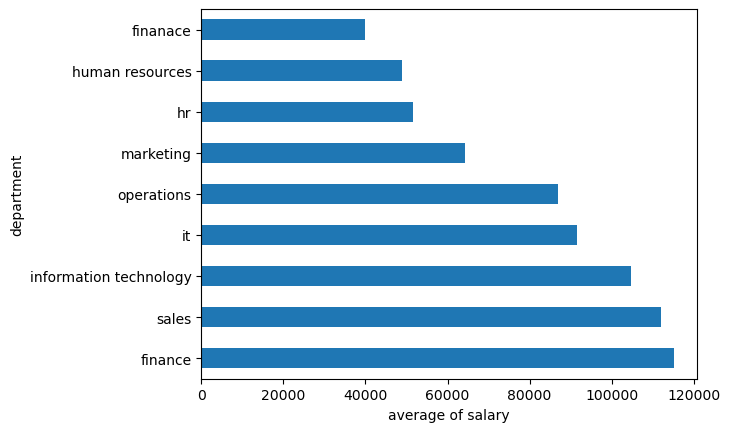

In [8]:
# visualization

# 1) Average Salary by Department
asd_plot = avg_salary_department.plot(x= 'department', y= 'salary', kind = 'barh', legend = False, xlabel = 'average of salary')
asd_plot


<Axes: xlabel='city', ylabel='count of employee'>

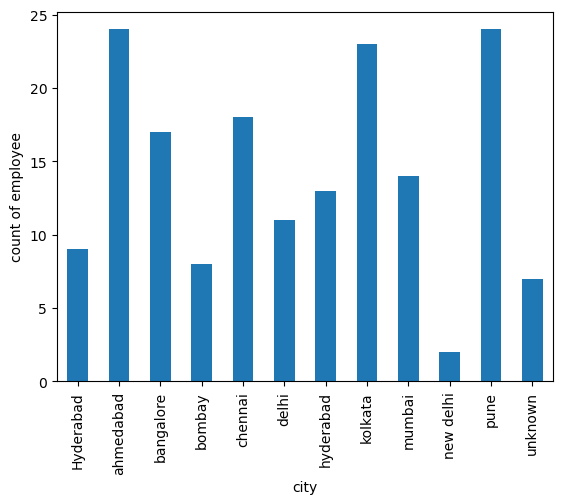

In [9]:
# 2) Employee Count by City

ec_plot = employee_count.plot(x = 'city', y= 'employee_id', kind= 'bar', legend = False, ylabel = 'count of employee' )

ec_plot


<Axes: xlabel='name', ylabel='salary'>

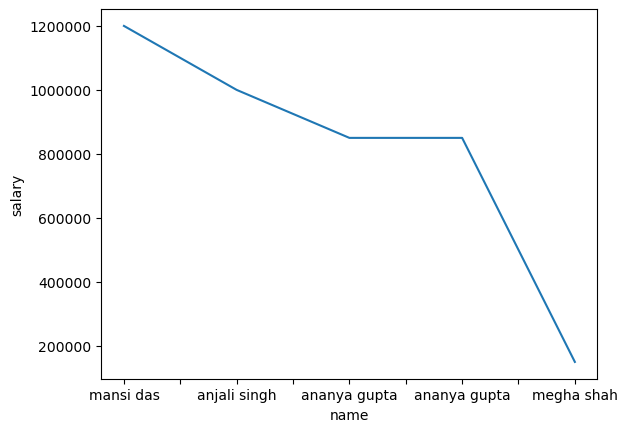

In [10]:
# 3) Top 5 Highest Paid Employees

hp_plot = high_paidd.plot(x= 'name', y = 'salary', kind = 'line', legend = False , ylabel = 'salary')
hp_plot.ticklabel_format(style='plain', axis='y')
hp_plot

<Axes: >

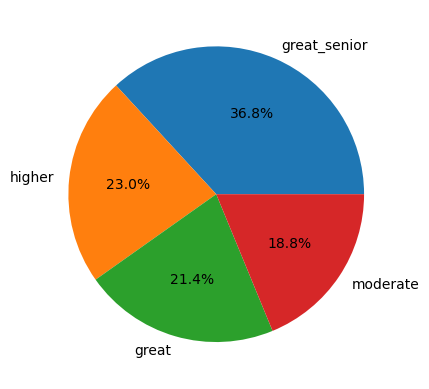

In [11]:
# 4) Salary vs Experience Level
se_plot = sal_exppp.plot(
    kind='pie',
    y='salary',
    labels=sal_exppp['exp_level_seg'],
    autopct='%1.1f%%',
    legend=False,
    ylabel=''
)

se_plot


<Axes: xlabel='department', ylabel='sum of salary'>

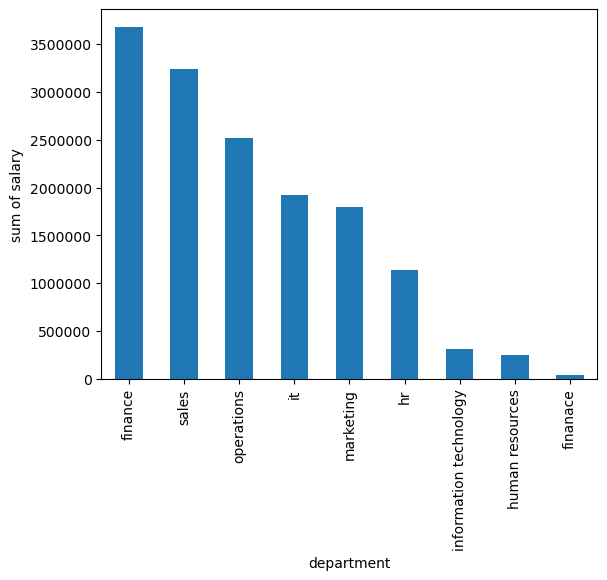

In [12]:
# 6) Department-wise Total Salary Expense

dts_plot = dep_tot_sal.plot(x = 'department', y = 'salary', legend = False, ylabel = 'sum of salary', kind = 'bar')
dts_plot.ticklabel_format( style = 'plain', axis = 'y')
dts_plot

<Axes: >

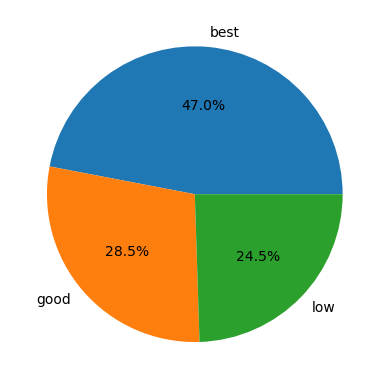

In [13]:
# 7) Performance vs Salary

perform_sal = perform_sal.plot(
    kind='pie',
    y='salary',
    labels=perform_sal['perform_seg'],
    autopct='%1.1f%%',
    legend=False,
    ylabel=''
)
perform_sal

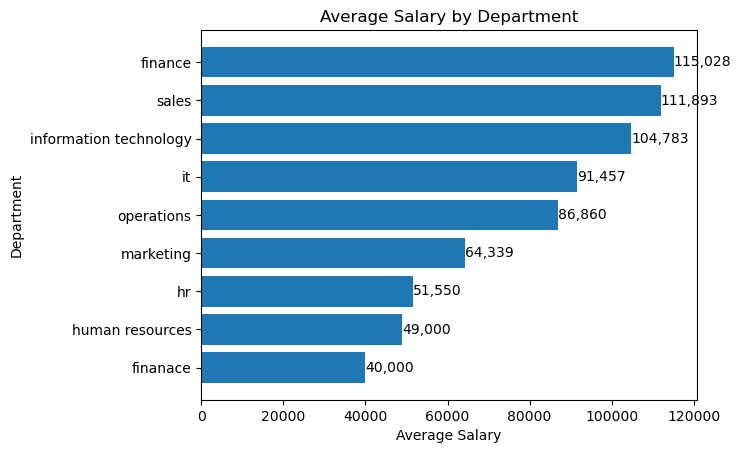

In [23]:
# some imp charts using the matplotlib


import matplotlib.pyplot as plt


# 1) Average Salary by Department


plt.figure()

plt.barh(avg_salary_department["department"], avg_salary_department["salary"])

plt.xlabel("Average Salary")
plt.ylabel("Department")
plt.title("Average Salary by Department")

plt.gca().invert_yaxis()

for i, v in enumerate(avg_salary_department["salary"]):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.show()


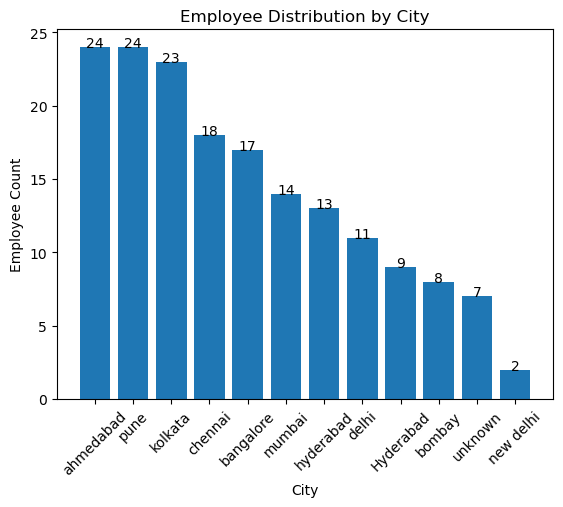

In [24]:
# 2) Employee Count by City

plt.figure()

employee_count_sorted = employee_count.sort_values(ascending=False)

plt.bar(employee_count_sorted.index, employee_count_sorted.values)

plt.xlabel("City")
plt.ylabel("Employee Count")
plt.title("Employee Distribution by City")

plt.xticks(rotation=45)

for i, v in enumerate(employee_count_sorted.values):
    plt.text(i, v, str(v), ha='center')

plt.show()



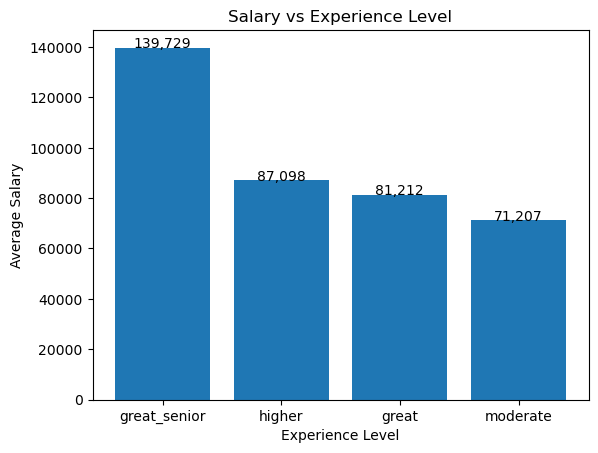

In [25]:
# 3) Salary vs Experience Level

plt.figure()

plt.bar(sal_exppp["exp_level_seg"], sal_exppp["salary"])

plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.title("Salary vs Experience Level")

for i, v in enumerate(sal_exppp["salary"]):
    plt.text(i, v, f"{v:,.0f}", ha='center')

plt.show()

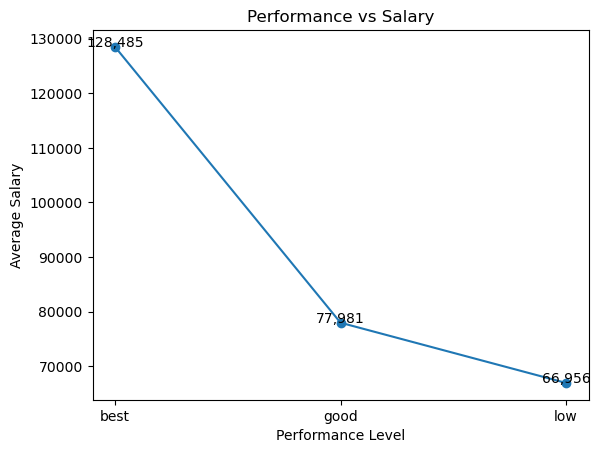

In [31]:
# 4) Performance vs Salary


plt.figure()

plt.plot(perform_sal["perform_seg"], perform_sal["salary"], marker='o')

plt.xlabel("Performance Level")
plt.ylabel("Average Salary")
plt.title("Performance vs Salary")

# Data labels
for i, v in enumerate(perform_sal["salary"]):
    plt.text(perform_sal["perform_seg"][i], v, f"{v:,.0f}", ha='center')

plt.show()

In [14]:
 # Insights from Employee Data Analysis

# 1. The Finance department has the highest 
#    average salary, suggesting that roles in this area may require specialized skills and 
#    therefore command higher compensation. In contrast, Human Resources has the lowest
#    average salary, indicating comparatively lower pay levels.

# 2. Pune and Ahmedabad have the highest employee count (24 each), making them the primary workforce hubs. 
#    On the other hand, New Delhi has the lowest employee count (2), indicating minimal organizational presence 
#    in that location.

# 3. The highest-paid employee in the dataset is Mansi Das, highlighting
#    a noticeable variation in salary distribution across employees.

# 4. Salary analysis across experience levels shows a clear upward trend, where Great 
#    Senior employees earn the highest salaries, followed by High, Great, and Moderate levels. 
#    This indicates that experience plays a major role in compensation growth.

# 5. The Finance department has a total salary expenditure of 3,720,898.77, making it the most
#    costly department in terms of payroll, which may reflect both higher salaries and workforce concentration.

# 6. When grouping performance ratings:

#   * Rating 5 (Best) employees receive the highest salaries
#   * Ratings 3–4 (Good) receive moderate compensation
#   * Ratings 1–2 (Low) receive the lowest salaries

#   This shows a strong positive relationship between performance and salary, indicating that better-performing
#   employees are rewarded with higher pay.

# 7. The year 2021 recorded the highest hiring activity (14 employees), suggesting a potential expansion 
#    phase or increased hiring demand during that period.




In [15]:
emp.to_csv("cleaned_employee_dataset.csv", index = False )